In [1]:
import os
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import textwrap

In [2]:
animals=['589L',
        '989N',
        '992N',
        '992L',
        '994R',
        '9972R',
        '217R',
        '217N',
        '218L',
        '034R',
        '149L',
        '146R',
        '160R',
        '492N',
        '493R',
        '1912L']

FOVs=[['FOV1','FOV2'],
['FOV1','FOV2'],
['FOV2'],
['FOV2'],
['FOV1','FOV2'],
['FOV1','FOV2'],
['FOV1'],
['FOV1','FOV2'],
['FOV1','FOV2'],
['FOV1'],
['FOV1','FOV2'],
['FOV2'],
['FOV1','FOV2'],
 ['FOV1','FOV2'],
 ['FOV1'],
 ['FOV1','FOV2']]

file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
info = pd.read_csv(file_key)
df_ = pd.DataFrame()
for a,ani in enumerate(animals):
    group = info['Group'].loc[info['Animal']==ani].values[0]
    fovs = FOVs[a]
    for fov in fovs:
        df = pd.read_csv(f"/Volumes/AM_SSD1/Spont2P/Analysis/mcherry/local_bg/{ani}_{fov}_local_int_regcells.csv")
        df['Animal'] = [ani]*df.shape[0]
        df['Group'] = [group]*df.shape[0]
        df_ = pd.concat([df_,df],ignore_index = True)
df_=df_.drop('Unnamed: 0',axis=1)

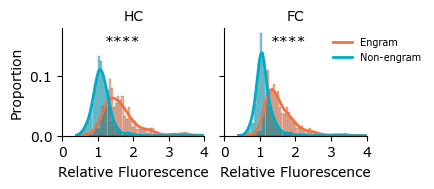

In [3]:
rcParams['lines.linewidth']=2
rcParams['font.family']='Verdana'
rcParams["svg.fonttype"]='none'

g=sb.displot(data=df_.loc[df_['Session']=='Post'],col='Group',hue='Tagged',x='Relative Intensity',palette=['#00ABC8','#F37243'],kde=True,stat='proportion',common_norm=False,height=2,aspect=1)
for ax in g.axes.flat:
    ax.set_xlim(0,4)
    ax.set_xlim(0,.22)
    ax.set_xticks([0,1,2,3,4])
g.axes[0,0].set_title('HC',size=10)
g.axes[0,0].set_xlabel('Relative Fluorescence',size=10,wrap=True)
g.axes[0,0].text(1.7,.15,'****',ha='center')

g.axes[0,1].set_title('FC',size=10)
g.axes[0,1].set_xlabel('Relative Fluorescence',size=10,wrap=True)
g.axes[0,1].text(1.8,.15,'****',ha='center')

for ax in g.axes.flatten():
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=10,
                      break_long_words=False))
    ax.set_xticklabels(labels, rotation=0)


g.legend.remove()
plt.legend(labels=['Engram','Non-engram'],bbox_to_anchor=(.7,1),fontsize=7,frameon=False)
plt.savefig('Fig1D.svg',transparent=True)

In [4]:
hc = df_.loc[(df_['Session']=='Post')&(df_['Group']=='HC')]
fc = df_.loc[(df_['Session']=='Post')&(df_['Group']=='FC')]

In [5]:
import pingouin as pg 
pg.normality(hc,dv='Relative Intensity', group='Tagged')

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


,W,pval,normal
Tagged,,,
1,0.873390,5.128365e-19,False
0,0.662066,1.037264e-38,False


In [6]:
pg.mwu(hc['Relative Intensity'].loc[hc.Tagged==1],hc['Relative Intensity'].loc[hc.Tagged==0])

,U-val,alternative,p-val,RBC,CLES
MWU,363604.0,two-sided,4.500415e-115,-0.753238,0.876619


In [7]:
pg.normality(fc,dv='Relative Intensity', group='Tagged')

,W,pval,normal
Tagged,,,
0,0.712165,1.584148e-33,False
1,0.879419,7.403094e-19,False


In [8]:
pg.mwu(fc['Relative Intensity'].loc[fc.Tagged==1],fc['Relative Intensity'].loc[fc.Tagged==0])

,U-val,alternative,p-val,RBC,CLES
MWU,308863.0,two-sided,1.881760e-113,-0.76902,0.88451
